<a href="https://colab.research.google.com/github/emanhassan2020/DiffusionModels/blob/main/huggingFaceCourse/Introduction/TrainCelebAHQ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
!pip install diffusers transformers accelerate torch

  Using cached triton-3.7.1-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (1.7 kB)
Using cached triton-3.7.1-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (197.7 MB)


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import torch

image_size = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
from huggingface_hub import notebook_login

notebook_login()

In [4]:
from datasets import load_dataset

ds = load_dataset("mattymchen/celeba-hq")

README.md:   0%|          | 0.00/539 [00:00<?, ?B/s]

data/train-00000-of-00006-bae07ad6d4d89a(…): reconstructing file:   0%|          |  0.00B /  454MB            

data/train-00000-of-00006-bae07ad6d4d89a(…): downloading bytes:           |  0.00B            

data/train-00001-of-00006-77346f9096557a(…): reconstructing file:   0%|          |  0.00B /  456MB            

data/train-00001-of-00006-77346f9096557a(…): downloading bytes:           |  0.00B            

...

data/train-00005-of-00006-2ad819c3650dbd(…): downloading bytes:           |  0.00B            

data/validation-00000-of-00001-a47eeed86(…): reconstructing file:   0%|          |  0.00B /  181MB            

data/validation-00000-of-00001-a47eeed86(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/28000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [5]:
from dataclasses import dataclass

@dataclass
class TrainingConfig:
    image_size = 128  # the generated image resolution
    train_batch_size = 16
    eval_batch_size = 16  # how many images to sample during evaluation
    num_epochs = 50
    gradient_accumulation_steps = 1
    learning_rate = 1e-4
    lr_warmup_steps = 500
    save_image_epochs = 10
    save_model_epochs = 30
    mixed_precision = 'fp16'  # `no` for float32, `fp16` for automatic mixed precision
    output_dir = 'ddpm-butterflies-128'  # the model namy locally and on the HF Hub

    push_to_hub = True  # whether to upload the saved model to the HF Hub
    hub_private_repo = False
    overwrite_output_dir = True  # overwrite the old model when re-running the notebook
    seed = 0

config = TrainingConfig()

In [6]:
from datasets import load_dataset

config.dataset_name = "mattymchen/celeba-hq"
ds = load_dataset(config.dataset_name, split="train")


In [16]:
!pip uninstall torch torchvision -y
!pip install torch torchvision

  Using cached torch-2.13.0-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (38 kB)
  Using cached triton-3.7.1-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (1.7 kB)
Using cached torch-2.13.0-cp313-cp313-manylinux_2_28_x86_64.whl (526.6 MB)
Using cached triton-3.7.1-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (197.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 36.2 MB/s eta 0:00:00


In [16]:
from torchvision import transforms

preprocess = transforms.Compose(
    [
        transforms.Resize((config.image_size, config.image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]
)
def transform(examples):
    images = [preprocess(image.convert("RGB")) for image in examples["image"]]
    return {"images": images}

ds.set_transform(transform)

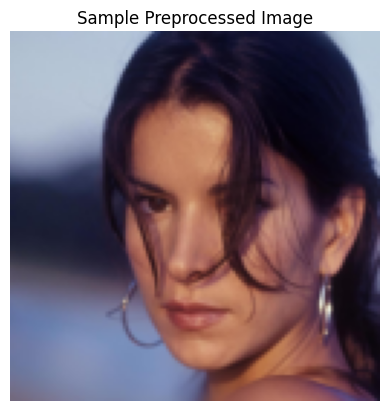

In [10]:
# Display a sample image to check the transformation
import matplotlib.pyplot as plt

sample_image_tensor = ds[10]["images"]
sample_image_pil = transforms.ToPILImage()(sample_image_tensor * 0.5 + 0.5) # De-normalize for display
plt.imshow(sample_image_pil)
plt.axis('off')
plt.title('Sample Preprocessed Image')
plt.show()

In [12]:
import torch

train_dataloader = torch.utils.data.DataLoader(ds, batch_size=config.train_batch_size, shuffle=True)

In [17]:
from diffusers import UNet2DModel


model = UNet2DModel(
    sample_size=config.image_size,  # the target image resolution
    in_channels=3,  # the number of input channels, 3 for RGB images
    out_channels=3,  # the number of output channels
    layers_per_block=2,  # how many ResNet layers to use per UNet block
    block_out_channels=(128, 128, 256, 256, 512, 512),  # the number of output channes for each UNet block
    down_block_types=(
        "DownBlock2D",  # a regular ResNet downsampling block
        "DownBlock2D",
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",  # a ResNet downsampling block with spatial self-attention
        "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D",  # a regular ResNet upsampling block
        "AttnUpBlock2D",  # a ResNet upsampling block with spatial self-attention
        "UpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
        "UpBlock2D"
      ),
)

RuntimeError: Failed to import diffusers.models.unets.unet_2d because of the following error (look up to see its traceback):
Failed to import diffusers.loaders.peft because of the following error (look up to see its traceback):
Could not import module 'BloomPreTrainedModel'. Are this object's requirements defined correctly?

In [ ]:
from torch.utils.data import DataLoader

def collate_fn(examples):
    images = torch.stack([example["images"] for example in examples])
    images = images.to(memory_format=torch.contiguous_format).float()
    return {"images": images}


train_dataloader = DataLoader(
    ds,
    batch_size=8,
    shuffle=True,
    collate_fn=collate_fn,
)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get a batch of images from the DataLoader
batch = next(iter(train_dataloader))
sample_images = batch["images"].cpu().numpy()

# Create a figure to display the images
fig, axes = plt.subplots(1, min(len(sample_images), 8), figsize=(15, 5))

for i, ax in enumerate(axes.flat):
    if i < len(sample_images):
        image = sample_images[i]
        # Denormalize the image from [-1, 1] to [0, 1]
        image = (image * 0.5 + 0.5).transpose(1, 2, 0) # Convert from (C, H, W) to (H, W, C)
        ax.imshow(image)
        ax.axis('off')
    else:
        ax.axis('off') # Hide empty subplots

plt.suptitle('Sample Preprocessed Images from Training Dataset', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
from diffusers import UNet2DModel

# Create a model
model = UNet2DModel(
    sample_size=image_size,  # the target image resolution
    in_channels=3,  # the number of input channels, 3 for RGB images
    out_channels=3,  # the number of output channels
    layers_per_block=2,  # how many ResNet layers to use per UNet block
    block_out_channels=(64, 128, 128, 256),  # More channels -> more parameters
    down_block_types=(
        "DownBlock2D",  # a regular ResNet downsampling block
        "DownBlock2D",
        "AttnDownBlock2D",  # a ResNet downsampling block with spatial self-attention
        "AttnDownBlock2D",
    ),
    up_block_types=(
        "AttnUpBlock2D",
        "AttnUpBlock2D",  # a ResNet upsampling block with spatial self-attention
        "UpBlock2D",
        "UpBlock2D",  # a regular ResNet upsampling block
    ),
)
model.to(device);

In [ ]:
from diffusers import DDPMScheduler
from torch.optim import AdamW

noise_scheduler = DDPMScheduler(num_train_timesteps=1000)
optimizer = AdamW(model.parameters(), lr=1e-4)

In [ ]:
from tqdm.auto import tqdm
import torch.nn.functional as F

# Training parameters
num_epochs = 1 # Changed to 1 epoch

# Put model in training mode
model.train()

losses = []

for epoch in range(num_epochs):
    for step, batch in enumerate(tqdm(train_dataloader, desc=f"Epoch {epoch}")):
        # Get the input images
        clean_images = batch["images"].to(device)

        # Sample noise to add to the images
        noise = torch.randn(clean_images.shape).to(device)

        # Sample a random timestep for each image
        timesteps = torch.randint(
            0, noise_scheduler.num_train_timesteps, (clean_images.shape[0],)
        ).to(device)

        # Add noise to the clean images according to the noise magnitude at each timestep
        noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

        # Get the model's prediction for the noise
        noise_pred = model(noisy_images, timesteps).sample

        # Calculate the loss
        loss = F.mse_loss(noise_pred, noise)
        loss.backward(loss)
        optimizer.step()
        optimizer.zero_grad()

        losses.append(loss.item())

        # Log periodically
        if (step + 1) % 100 == 0:
            print(f"Epoch {epoch}, Step {step+1}: Loss {loss.item():.4f}")

    # Optionally save model weights after each epoch (or every few epochs)
    # torch.save(model.state_dict(), f"diffusion_model_epoch_{epoch}.pt")

print("Training complete!")

### Save the trained model

In [ ]:
import os

# Define the path to save the model in Google Drive
model_save_path = '/content/drive/MyDrive/diffusion_model.pt'

# Ensure the directory exists (if saving to a subdirectory within MyDrive)
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

# Save the model's state dictionary
torch.save(model.state_dict(), model_save_path)

print(f"Model saved to: {model_save_path}")

### Training Loss Curve

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Training Loss Curve')
plt.xlabel('Training Steps')
plt.ylabel('Loss (MSE)')
plt.grid(True)
plt.show()

### Sample from the Trained Model

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from diffusers import DDPMScheduler

# Put the model in evaluation mode
model.eval()

# Generate a random noise vector as the starting point for sampling
sample_batch_size = 4 # Number of images to generate
sample_shape = (sample_batch_size, model.in_channels, model.sample_size, model.sample_size)

# Start with pure noise
sample = torch.randn(sample_shape).to(device)

# Initialize the noise scheduler for inference (sampling)
# We'll use the same scheduler, but its `set_timesteps` method prepares it for inference
noise_scheduler.set_timesteps(1000) # Use 1000 timesteps for sampling

# Denoising loop
with torch.no_grad(): # Disable gradient calculations for inference
    for t in tqdm(noise_scheduler.timesteps, desc="Sampling"): # Iterate through timesteps from T down to 0
        # 1. Predict noise residual
        noise_pred = model(sample, t).sample

        # 2. Compute previous image sample (x_t-1) using the scheduler
        sample = noise_scheduler.step(noise_pred, t, sample).prev_sample

# Denormalize the generated images from [-1, 1] to [0, 1] for display
sample_images = (sample * 0.5 + 0.5).clamp(0, 1).cpu().numpy()

# Convert from (Batch, Channels, Height, Width) to (Batch, Height, Width, Channels) for matplotlib
sample_images = sample_images.transpose(0, 2, 3, 1)

# Display the generated images
fig, axes = plt.subplots(1, sample_batch_size, figsize=(15, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_images[i])
    ax.axis('off')

plt.suptitle('Generated Images from Trained Model', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
import torch
from diffusers import DiffusionPipeline

# Load the CelebA-HQ trained pipeline
#pipe = DiffusionPipeline.from_pretrained("google/ddpm-celebahq-256", dtype=torch.bfloat16)
#pipe.to("cuda")

# Generate an image
#image = pipe().images[0]
#image.save("generated_face.png")

In [18]:
!pip uninstall -y diffusers transformers accelerate
!pip install diffusers transformers accelerate

Found existing installation: diffusers 0.40.0
Uninstalling diffusers-0.40.0:
  Successfully uninstalled diffusers-0.40.0
Found existing installation: transformers 5.15.1
Uninstalling transformers-5.15.1:
  Successfully uninstalled transformers-5.15.1
Found existing installation: accelerate 1.14.0
Uninstalling accelerate-1.14.0:
  Successfully uninstalled accelerate-1.14.0
  Using cached diffusers-0.40.0-py3-none-any.whl.metadata (20 kB)
  Using cached transformers-5.15.1-py3-none-any.whl.metadata (32 kB)
  Using cached triton-3.7.1-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (1.7 kB)
Using cached diffusers-0.40.0-py3-none-any.whl (5.9 MB)
Using cached transformers-5.15.1-py3-none-any.whl (11.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 3.9 MB/s eta 0:00:00
Using cached triton-3.7.1-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (197.7 MB)
